![Universidad Espíritu Santo](https://raw.githubusercontent.com/andresrubiop/miar0525-estudiantes/main/utils/logo-uees-color.png)

<div style="background:#821436;color:#FFFFFF;padding:14px 18px;border-radius:10px;margin:6px 0 12px 0"><div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;opacity:.9">Aprendizaje Automático · MIAR0525 · Semana 4 · Versión resuelta · referencia</div><div style="font-size:22px;font-weight:700;margin-top:4px">E4.3 · Explicabilidad, Model Card y monitoreo</div><div style="font-size:12px;opacity:.9;margin-top:4px">Postgrado · Maestría en Inteligencia Artificial · UEES</div></div>

| | |
|---|---|
| **Objetivo** | Explicar un modelo de forma global (permutación, PDP) e individual (ICE, SHAP), documentarlo en una Model Card con métricas desagregadas y diseñar su monitoreo en producción (drift de datos y de concepto), registrándolo en MLflow. |
| **Resultado de aprendizaje** | RDA1 y RDA2 · competencias CG-G1, CE-G1 y CE-G2 (según el sílabo) |
| **Duración** | ≈ 5 h |
| **Teoría** | Manual M4 §4, §5 y §7 · Animaciones A4.3–A4.7 · Videos V4.3 y V4.4 · Molnar (BB6) · Mitchell et al. (2019), *Model Cards* (BC4) · Huyen (2022) (BC2) |
| **Datos** | **Diabetes 130-Hospitals** (`fairlearn.datasets.fetch_diabetes_hospital`), el mismo modelo de reingreso de E4.2 |

**Niveles:** 1 · importancia por permutación desde cero → 2 · `permutation_importance`, PDP/ICE y SHAP → 3 · Model Card, drift simulado (PSI y KS) y plan de monitoreo → 4 · reto: registrar el modelo con su tarjeta en MLflow.

## 0 · Configuración

In [1]:
import contextlib
import logging
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from cycler import cycler
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", message="IProgress not found")
for paquete in ("fairlearn", "shap", "mlflow"):          # en Colab: se instalan una sola vez
    try:
        __import__(paquete)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete])
import mlflow
import shap

logging.getLogger("mlflow").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
SEED = 2026
UEES = {"vino": "#821436", "azul": "#1F6F8B", "ocre": "#C28E0E", "verde": "#3A7D44", "gris": "#77787B"}
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=list(UEES.values())), "axes.titlecolor": UEES["vino"],
    "axes.titleweight": "bold", "axes.edgecolor": UEES["gris"], "axes.grid": True, "grid.color": "#EEE8EA",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
print(f"scikit-learn {sklearn.__version__} · SHAP {shap.__version__} · MLflow {mlflow.__version__} · semilla {SEED}")

scikit-learn 1.9.1 · SHAP 0.52.0 · MLflow 3.16.0 · semilla 2026


### El modelo de E4.2
Reconstruimos el mismo modelo de reingreso en 30 días: regresión logística con pesos balanceados, sin raza ni género como variables. Las variables enteras pasan a decimales (lo exige el cálculo de PDP de scikit-learn).

In [2]:
from fairlearn.datasets import fetch_diabetes_hospital
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

D = fetch_diabetes_hospital(as_frame=True).frame
D = D[D["gender"] != "Unknown/Invalid"].copy()
for c in D.select_dtypes(["string", "object", "category"]).columns:
    D[c] = D[c].astype(str).str.strip("'").astype("category")
y = D.pop("readmit_30_days")
D = D.drop(columns=["readmitted", "readmit_binary"])
sensibles = D[["race", "gender", "age"]].copy()
sensibles["raza"] = sensibles["race"].astype(str).replace({"Asian": "Otra", "Hispanic": "Otra", "Other": "Otra", "Unknown": "Desconocida"})
X = D.drop(columns=["race", "gender"])
numericas = X.select_dtypes("number").columns.tolist()
categoricas = X.select_dtypes("category").columns.tolist()
X[numericas] = X[numericas].astype(float)

X_tr, X_te, y_tr, y_te, s_tr, s_te = train_test_split(X, y, sensibles, test_size=0.3, stratify=y, random_state=SEED)
prep = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoricas),
                          ("num", StandardScaler(), numericas)])
modelo = make_pipeline(prep, LogisticRegression(max_iter=2000, class_weight="balanced")).fit(X_tr, y_tr)
auc_base = roc_auc_score(y_te, modelo.predict_proba(X_te)[:, 1])
print(f"AUC en la prueba: {auc_base:.3f} · {X.shape[1]} variables ({len(categoricas)} categóricas, {len(numericas)} numéricas)")

AUC en la prueba: 0.638 · 20 variables (15 categóricas, 5 numéricas)


## Nivel 1 · Importancia por permutación desde cero (prelaboratorio)

Si barajamos una columna, rompemos su relación con el objetivo y con las demás variables. Cuánto cae la métrica mide **cuánto depende el modelo** de esa variable. Usamos 10 000 pacientes de la prueba y 5 repeticiones por variable.

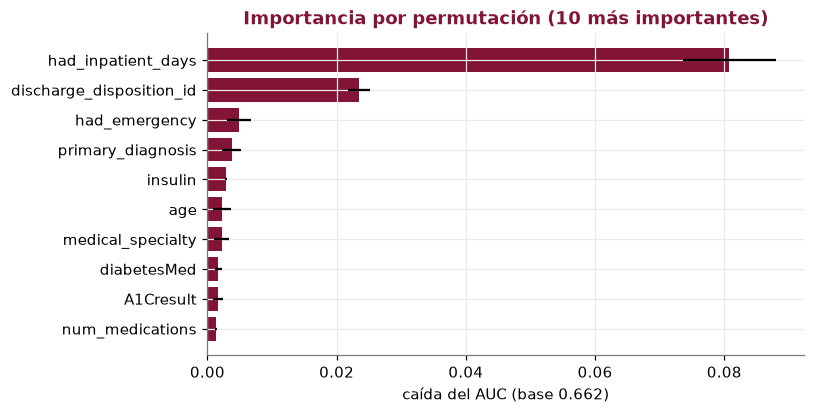

,caída de AUC,desviación
had_inpatient_days,0.0808,0.0072
discharge_disposition_id,0.0234,0.0017
had_emergency,0.0049,0.0019
primary_diagnosis,0.0038,0.0015
insulin,0.0029,0.0001
age,0.0022,0.0014


In [3]:
muestra = X_te.sample(10000, random_state=SEED)
y_muestra = y_te.loc[muestra.index]
auc_muestra = roc_auc_score(y_muestra, modelo.predict_proba(muestra)[:, 1])


def importancia_permutacion(modelo, X, y, repeticiones=5, semilla=SEED):
    """Caída media (y su desviación) del AUC al barajar cada columna."""
    r = np.random.default_rng(semilla)
    base = roc_auc_score(y, modelo.predict_proba(X)[:, 1])
    resultado = {}
    for col in X.columns:
        caidas = []
        for _ in range(repeticiones):
            # TODO: copia X, baraja solo la columna `col` con r.permutation y guarda base − AUC del modelo sobre la copia.
            Xp = X.copy()
            Xp[col] = Xp[col].to_numpy()[r.permutation(len(Xp))]
            caidas.append(base - roc_auc_score(y, modelo.predict_proba(Xp)[:, 1]))
        resultado[col] = {"caída de AUC": np.mean(caidas), "desviación": np.std(caidas)}
    return pd.DataFrame(resultado).T.sort_values("caída de AUC", ascending=False)


imp_propia = importancia_permutacion(modelo, muestra, y_muestra)
top = imp_propia.head(10)[::-1]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(top.index, top["caída de AUC"], xerr=top["desviación"], color=UEES["vino"])
ax.set(title="Importancia por permutación (10 más importantes)", xlabel=f"caída del AUC (base {auc_muestra:.3f})")
plt.show()
imp_propia.head(6).round(4)

**Qué observar.** El modelo depende sobre todo de si el paciente tuvo **hospitalizaciones previas** (`had_inpatient_days`) y de a dónde se le dio el alta; barajar cualquiera de las otras variables casi no cambia el AUC. Importancia por permutación = **dependencia del modelo**, no causalidad: no dice que evitar hospitalizaciones previas reduzca el reingreso, ni que una variable poco importante no se relacione con el objetivo (puede estar "cubierta" por otra correlacionada).

## Nivel 2 · Con scikit-learn y SHAP

### 2.1 `permutation_importance`

In [4]:
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance

pi = permutation_importance(modelo, muestra, y_muestra, scoring="roc_auc", n_repeats=5, random_state=SEED)
imp_sk = pd.Series(pi.importances_mean, index=muestra.columns).sort_values(ascending=False)
rho = spearmanr(imp_propia["caída de AUC"], imp_sk.reindex(imp_propia.index)).statistic
print(f"Correlación de rangos entre tu importancia y la de scikit-learn: {rho:.3f}")
print("Las 3 más importantes · tuyas:", imp_propia.index[:3].tolist(), "· scikit-learn:", imp_sk.index[:3].tolist())
assert rho > 0.9 and imp_propia.index[0] == imp_sk.index[0]
print("✓ Tu importancia por permutación coincide con scikit-learn (las permutaciones al azar difieren)")

Correlación de rangos entre tu importancia y la de scikit-learn: 0.953
Las 3 más importantes · tuyas: ['had_inpatient_days', 'discharge_disposition_id', 'had_emergency'] · scikit-learn: ['had_inpatient_days', 'discharge_disposition_id', 'had_emergency']
✓ Tu importancia por permutación coincide con scikit-learn (las permutaciones al azar difieren)


### 2.2 PDP e ICE: el promedio puede ocultar
El **PDP** muestra cómo cambia la predicción media al mover una variable; las curvas **ICE** muestran lo mismo para cada paciente. Comparamos la regresión logística con un modelo de boosting sobre los mismos datos.

AUC del boosting: 0.641 (logística: 0.638)


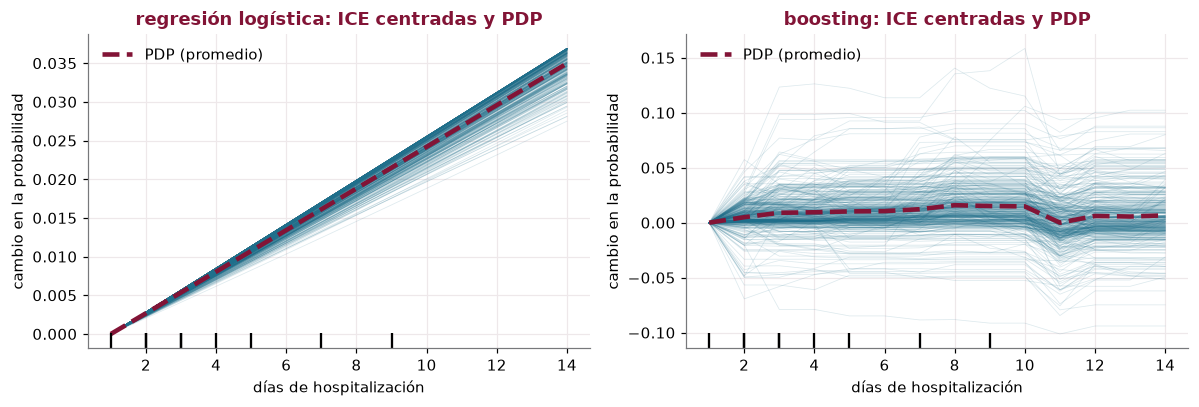

Fracción de curvas ICE que suben con los días de hospitalización: {'regresión logística': 1.0, 'boosting': 0.58}


In [5]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay, partial_dependence

boosting = HistGradientBoostingClassifier(categorical_features="from_dtype", max_iter=300, learning_rate=0.05, random_state=SEED).fit(X_tr, y_tr)
print(f"AUC del boosting: {roc_auc_score(y_te, boosting.predict_proba(X_te)[:, 1]):.3f} (logística: {auc_base:.3f})")
pacientes = X_te.sample(400, random_state=SEED)
variable = "time_in_hospital"
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
suben = {}
for ax, (nombre, mod) in zip(axes, (("regresión logística", modelo), ("boosting", boosting))):
    disp = PartialDependenceDisplay.from_estimator(mod, pacientes, [variable], kind="both", centered=True, ax=ax,
                                                   ice_lines_kw={"alpha": 0.15, "color": UEES["azul"]},
                                                   pd_line_kw={"color": UEES["vino"], "lw": 3, "label": "PDP (promedio)"})
    disp.axes_[0][0].set(title=f"{nombre}: ICE centradas y PDP", ylabel="cambio en la probabilidad", xlabel="días de hospitalización")
    ice = partial_dependence(mod, pacientes, [variable], kind="individual", grid_resolution=15)["individual"][0]
    # TODO: fracción de pacientes cuya curva ICE termina más arriba de donde empieza.
    suben[nombre] = float(np.mean(ice[:, -1] > ice[:, 0]))
plt.tight_layout()
plt.show()
print("Fracción de curvas ICE que suben con los días de hospitalización:", {k: round(v, 2) for k, v in suben.items()})

**Qué observar.** En la regresión logística todas las curvas suben (el modelo es aditivo en la escala logit: solo cambia la pendiente por la forma de la sigmoide). En el boosting, el PDP también sube un poco, pero **no para todos**: una parte de las curvas ICE baja o queda plana. El promedio oculta interacciones; por eso se mira el PDP junto con las ICE. Y ambas suponen que se puede mover una variable dejando las demás fijas, algo irreal cuando están correlacionadas.

### 2.3 SHAP: explicar un caso
SHAP reparte la predicción de un paciente (en log-odds) entre sus variables, partiendo del **valor base** (la predicción promedio). Para un modelo lineal con variables independientes, el valor SHAP de una variable es \(\beta_j (x_j - \bar x_j)\): lo comprobamos.

✓ SHAP del modelo lineal = β·(x − media)


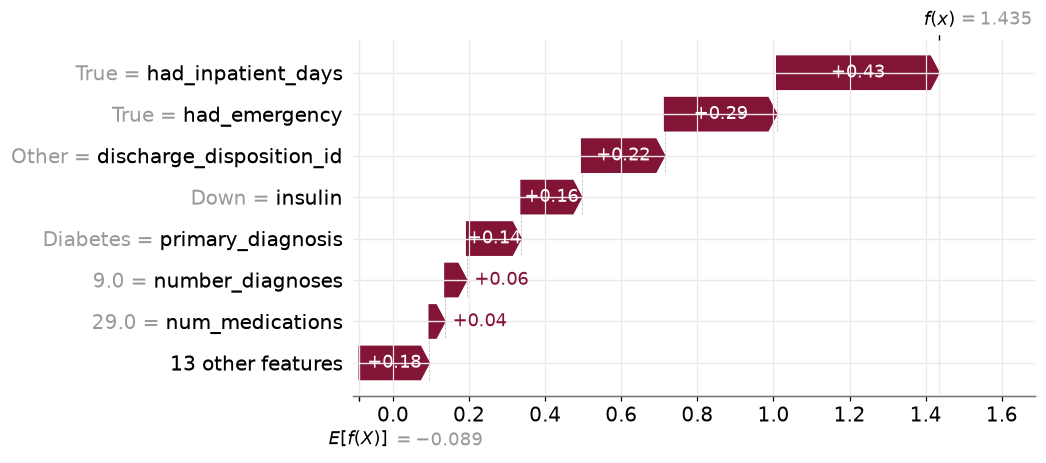

Riesgo predicho del caso: 0.808 · log-odds: valor base -0.09 + suma de SHAP 1.52


In [6]:
Z_tr, Z_te = modelo[0].transform(X_tr), modelo[0].transform(X_te)
nombres_z = modelo[0].get_feature_names_out()
logistica = modelo[-1]
explicador = shap.LinearExplainer(logistica, shap.maskers.Independent(Z_tr, max_samples=len(Z_tr)))
p_te = modelo.predict_proba(X_te)[:, 1]
caso = int(np.argmax(p_te))                                     # el paciente con mayor riesgo predicho
exp_caso = explicador(Z_te[[caso]])
# TODO: calcula a mano los valores SHAP del caso: coeficientes × (z del caso − media de Z_tr).
manual = logistica.coef_[0] * (Z_te[caso] - Z_tr.mean(axis=0))
assert np.allclose(exp_caso.values[0], manual, atol=1e-8)
print("✓ SHAP del modelo lineal = β·(x − media)")

# agrupamos las columnas one-hot en la variable original para leer la explicación
original = np.array([n.split("__", 1)[1].rsplit("_", 1)[0] if n.startswith("cat__") else n.split("__", 1)[1] for n in nombres_z])
for c in categoricas:                                            # nombres de categorías con "_" (p. ej. "Discharged to Home")
    original[[n.startswith(f"cat__{c}_") for n in nombres_z]] = c
agrupado = pd.Series(exp_caso.values[0], index=original).groupby(level=0).sum()
exp_agr = shap.Explanation(values=agrupado.to_numpy(), base_values=exp_caso.base_values[0],
                           data=X_te.iloc[caso][agrupado.index].astype(str).to_numpy(), feature_names=agrupado.index.tolist())
estilo = getattr(getattr(shap.plots, "_style", None), "style_context", None)   # colores UEES si la versión de SHAP lo permite
colores = dict(primary_color_positive=UEES["vino"], primary_color_negative=UEES["azul"],
               secondary_color_positive="#E6B8C6", secondary_color_negative="#B5D3DE")
with (estilo(**colores) if estilo else contextlib.nullcontext()):
    shap.plots.waterfall(exp_agr, max_display=8, show=False)
plt.gcf().set_size_inches(8, 4.2)
plt.show()
print(f"Riesgo predicho del caso: {p_te[caso]:.3f} · log-odds: valor base {exp_caso.base_values[0]:.2f} + suma de SHAP {agrupado.sum():.2f}")

**Qué observar.** La cascada suma, desde el valor base, la contribución de cada variable hasta llegar a la predicción del caso (en log-odds). Es una explicación **aditiva y local**: sirve para revisar un caso con el equipo clínico, no para afirmar causas. Con variables correlacionadas y modelos no lineales, SHAP depende del conjunto de referencia y del explicador; hay que decir cuáles se usaron.

## Nivel 3 · Model Card, drift y plan de monitoreo

### 3.1 La Model Card
Mitchell et al. (2019) proponen documentar cada modelo con: detalles, uso previsto, factores, métricas (desagregadas), datos de evaluación y de entrenamiento, consideraciones éticas y advertencias.

In [7]:
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate

pred_te = (p_te >= 0.5).astype(int)
desag = {a: MetricFrame(metrics={"selección": selection_rate, "TPR": true_positive_rate}, y_true=y_te, y_pred=pred_te,
                        sensitive_features=s_te[a]).by_group.round(2) for a in ("raza", "gender", "age")}
filas_desag = "\n".join(f"| {a} = {g} | {fila['selección']:.2f} | {fila['TPR']:.2f} |" for a, t in desag.items() for g, fila in t.iterrows())
tarjeta = f"""# Model Card · reingreso-diabetes (v1)

**Detalles.** Regresión logística con pesos balanceados (scikit-learn {sklearn.__version__}); preprocesamiento one-hot y estandarización en un pipeline. Autor: equipo de ciencia de datos · fecha: 2026-10.

**Uso previsto.** Priorizar pacientes con diabetes para un programa de seguimiento tras el alta. Apoyo a la decisión clínica, con revisión humana. **Usos fuera de alcance:** negar atención, fijar precios de seguros o evaluar el desempeño de médicos.

**Factores.** Raza (agrupada), género y grupo de edad. Raza y género no son variables del modelo; se usan solo para auditar.

**Métricas.** AUC {auc_base:.3f} en la prueba (30 %, {len(y_te)} hospitalizaciones); umbral 0.5 → {pred_te.mean():.0%} de pacientes seleccionados, recall {true_positive_rate(y_te, pred_te):.2f}.

| Grupo | Selección | TPR |
|---|---|---|
{filas_desag}

**Datos.** Diabetes 130-US Hospitals (1999–2008), versión de Fairlearn; 101 763 hospitalizaciones, 11.2 % con reingreso en 30 días. Partición aleatoria estratificada.

**Consideraciones éticas.** La TPR es menor para pacientes con raza desconocida (registros incompletos); ver la auditoría de E4.2. La mitigación con umbrales por grupo usa la raza al decidir.

**Advertencias.** Modelo débil (AUC ≈ 0.64): la mayoría de los seleccionados no se reingresa. Un paciente puede aparecer varias veces (sin identificador de paciente). Datos de hace más de 15 años: validar con datos locales recientes antes de usar.
"""
display(Markdown(tarjeta))

# Model Card · reingreso-diabetes (v1)

**Detalles.** Regresión logística con pesos balanceados (scikit-learn 1.9.1); preprocesamiento one-hot y estandarización en un pipeline. Autor: equipo de ciencia de datos · fecha: 2026-10.

**Uso previsto.** Priorizar pacientes con diabetes para un programa de seguimiento tras el alta. Apoyo a la decisión clínica, con revisión humana. **Usos fuera de alcance:** negar atención, fijar precios de seguros o evaluar el desempeño de médicos.

**Factores.** Raza (agrupada), género y grupo de edad. Raza y género no son variables del modelo; se usan solo para auditar.

**Métricas.** AUC 0.638 en la prueba (30 %, 30529 hospitalizaciones); umbral 0.5 → 40% de pacientes seleccionados, recall 0.58.

| Grupo | Selección | TPR |
|---|---|---|
| raza = AfricanAmerican | 0.41 | 0.58 |
| raza = Caucasian | 0.40 | 0.59 |
| raza = Desconocida | 0.26 | 0.42 |
| raza = Otra | 0.35 | 0.56 |
| gender = Female | 0.41 | 0.60 |
| gender = Male | 0.38 | 0.56 |
| age = 30 years or younger | 0.38 | 0.84 |
| age = 30-60 years | 0.31 | 0.55 |
| age = Over 60 years | 0.44 | 0.59 |

**Datos.** Diabetes 130-US Hospitals (1999–2008), versión de Fairlearn; 101 763 hospitalizaciones, 11.2 % con reingreso en 30 días. Partición aleatoria estratificada.

**Consideraciones éticas.** La TPR es menor para pacientes con raza desconocida (registros incompletos); ver la auditoría de E4.2. La mitigación con umbrales por grupo usa la raza al decidir.

**Advertencias.** Modelo débil (AUC ≈ 0.64): la mayoría de los seleccionados no se reingresa. Un paciente puede aparecer varias veces (sin identificador de paciente). Datos de hace más de 15 años: validar con datos locales recientes antes de usar.


### 3.2 Drift simulado
Simulamos seis meses de producción, 4 000 hospitalizaciones por mes, a partir de la prueba:
- **meses 1–3, drift de datos:** cada mes llegan más pacientes mayores de 60 con hospitalizaciones previas;
- **meses 4–6, drift de concepto:** la población queda como en el mes 3, pero un nuevo protocolo de seguimiento reduce a la mitad los reingresos de quienes se van a casa. Las variables no cambian; lo que cambia es la relación entre ellas y el objetivo.

El **PSI** (índice de estabilidad poblacional) compara la distribución de referencia \(q\) con la actual \(p\) por intervalos: \(\text{PSI} = \sum_i (p_i - q_i)\ln(p_i / q_i)\). Regla práctica muy usada: < 0.1 estable, 0.1–0.25 revisar, > 0.25 actuar.

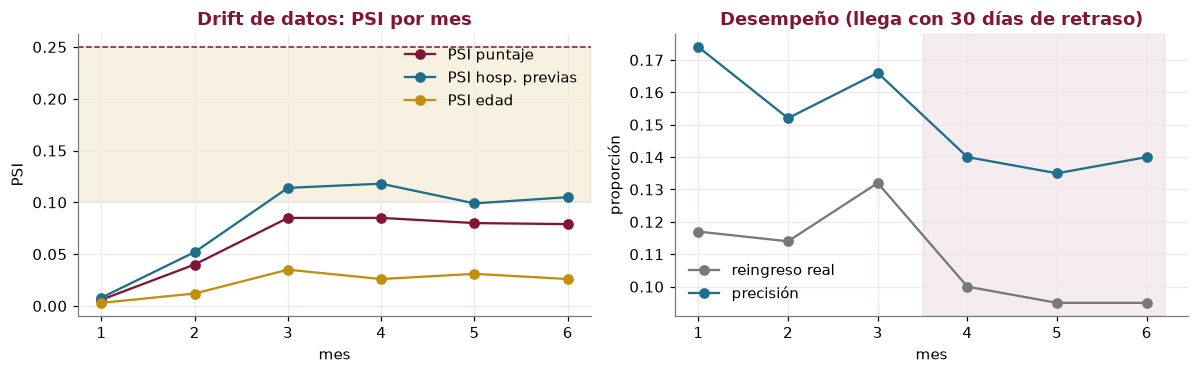

,PSI puntaje,PSI hosp. previas,PSI edad,KS medicamentos (p),seleccionados,reingreso real,precisión,recall
mes,,,,,,,,
1,0.006,0.008,0.003,0.585,0.436,0.117,0.174,0.651
2,0.040,0.052,0.012,0.285,0.494,0.114,0.152,0.658
3,0.085,0.114,0.035,0.775,0.534,0.132,0.166,0.675
4,0.085,0.118,0.026,0.065,0.534,0.100,0.140,0.752
5,0.080,0.099,0.031,0.016,0.524,0.095,0.135,0.745
6,0.079,0.105,0.026,0.033,0.525,0.095,0.140,0.776


In [8]:
from scipy.stats import ks_2samp


def psi(referencia, actual, intervalos=10):
    """PSI entre dos muestras: por deciles de la referencia (numéricas) o por categoría."""
    if isinstance(referencia.dtype, pd.CategoricalDtype):
        cats = referencia.cat.categories
        q = referencia.value_counts(normalize=True).reindex(cats).to_numpy()
        p = actual.value_counts(normalize=True).reindex(cats).fillna(0).to_numpy()
    else:
        # TODO: bordes en los deciles de la referencia (con −∞ y +∞ en los extremos) y proporciones con np.histogram.
        bordes = np.unique(np.quantile(referencia, np.linspace(0, 1, intervalos + 1)))
        bordes[0], bordes[-1] = -np.inf, np.inf
        q = np.histogram(referencia, bordes)[0] / len(referencia)
        p = np.histogram(actual, bordes)[0] / len(actual)
    q, p = np.clip(q, 1e-4, None), np.clip(p, 1e-4, None)
    return float(np.sum((p - q) * np.log(p / q)))


ref_puntaje = pd.Series(modelo.predict_proba(X_tr)[:, 1])
r = np.random.default_rng(SEED)
riesgo_alto = ((X_te["age"] == "Over 60 years") & (X_te["had_inpatient_days"] == "True")).to_numpy()
filas = []
for mes in range(1, 7):
    intensidad = {1: 0.3, 2: 0.8, 3: 1.5}.get(mes, 1.5)
    w = 1 + intensidad * riesgo_alto
    idx = r.choice(len(X_te), 4000, replace=True, p=w / w.sum())
    Xm, ym = X_te.iloc[idx], y_te.iloc[idx].to_numpy().copy()
    if mes >= 4:
        a_casa = (Xm["discharge_disposition_id"] == "Discharged to Home").to_numpy() & (ym == 1)
        ym[a_casa & (r.random(len(ym)) < 0.5)] = 0
    pm = modelo.predict_proba(Xm)[:, 1]
    sel = pm >= 0.5
    filas.append({"mes": mes, "PSI puntaje": psi(ref_puntaje, pd.Series(pm)), "PSI hosp. previas": psi(X_tr["had_inpatient_days"], Xm["had_inpatient_days"]),
                  "PSI edad": psi(X_tr["age"], Xm["age"]), "KS medicamentos (p)": ks_2samp(X_tr["num_medications"], Xm["num_medications"]).pvalue,
                  "seleccionados": sel.mean(), "reingreso real": ym.mean(), "precisión": ym[sel].mean(), "recall": ym[sel].sum() / ym.sum()})
monitoreo = pd.DataFrame(filas).set_index("mes").round(3)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
monitoreo[["PSI puntaje", "PSI hosp. previas", "PSI edad"]].plot(ax=axes[0], marker="o")
axes[0].axhspan(0.1, 0.25, color=UEES["ocre"], alpha=0.12)
axes[0].axhline(0.25, color=UEES["vino"], ls="--", lw=1)
axes[0].set(title="Drift de datos: PSI por mes", ylabel="PSI")
monitoreo[["reingreso real", "precisión"]].plot(ax=axes[1], marker="o", color=[UEES["gris"], UEES["azul"]])
axes[1].axvspan(3.5, 6.2, color=UEES["vino"], alpha=0.08)
axes[1].set(title="Desempeño (llega con 30 días de retraso)", ylabel="proporción")
plt.tight_layout()
plt.show()
monitoreo

**Qué observar.** En los meses 1–3 la población cambia: el PSI de las hospitalizaciones previas pasa de 0.01 a 0.11 (zona de revisión) y el del puntaje llega a 0.085, todavía "estable" según la regla práctica; la señal más clara es operativa: la tasa de seleccionados sube del 44 % al 53 %. La precisión se mantiene (0.15–0.17). En los meses 4–6 el PSI **se queda quieto** (la población es la del mes 3) y, sin embargo, el reingreso real baja del 13 % al 10 % y la precisión cae a 0.14: es **drift de concepto**, invisible para cualquier métrica que solo mire las variables. El recall incluso **sube**, porque los reingresos que desaparecieron eran los más difíciles de detectar: mirar una sola métrica engaña. Un plan de monitoreo combina la distribución de entradas y salidas (inmediata) con el desempeño cuando llegan las etiquetas (aquí, 30 días después). Y la prueba KS da p < 0.05 en los meses 5 y 6 aunque la población es la misma del mes 3: con miles de datos y pruebas repetidas cada mes aparecen "alarmas" por azar; el valor p dice si hay diferencia, no si importa.

### 3.3 Plan de monitoreo

In [9]:
plan = pd.DataFrame([
    {"qué se mide": "PSI del puntaje y de las 5 variables más importantes", "frecuencia": "semanal", "umbral": "PSI > 0.1 revisar · > 0.25 incidente", "responsable": "MLOps", "respuesta": "Analizar el origen; si persiste, reentrenar y revalidar"},
    {"qué se mide": "Tasa de seleccionados", "frecuencia": "semanal", "umbral": "fuera de 35–45 %", "responsable": "MLOps + coordinación del programa", "respuesta": "Ajustar el umbral a la capacidad del programa"},
    # TODO: agrega al menos dos filas más: desempeño con etiquetas (precisión y recall) y equidad (TPR por grupo).
    {"qué se mide": "Precisión y recall con las etiquetas de 30 días", "frecuencia": "mensual", "umbral": "caída > 5 puntos frente a la validación", "responsable": "Ciencia de datos", "respuesta": "Investigar drift de concepto; reentrenar con datos recientes"},
    {"qué se mide": "TPR por raza, género y edad (con intervalos)", "frecuencia": "trimestral", "umbral": "diferencia > 0.10 con intervalos que no se superponen", "responsable": "Comité de ética + ciencia de datos", "respuesta": "Auditoría; mitigación; revisar la calidad de los registros"},
])
display(plan)

,qué se mide,frecuencia,umbral,responsable,respuesta
0,PSI del puntaje y de las 5 variables más impor...,semanal,PSI > 0.1 revisar · > 0.25 incidente,MLOps,"Analizar el origen; si persiste, reentrenar y ..."
1,Tasa de seleccionados,semanal,fuera de 35–45 %,MLOps + coordinación del programa,Ajustar el umbral a la capacidad del programa
2,Precisión y recall con las etiquetas de 30 días,mensual,caída > 5 puntos frente a la validación,Ciencia de datos,Investigar drift de concepto; reentrenar con d...
3,"TPR por raza, género y edad (con intervalos)",trimestral,diferencia > 0.10 con intervalos que no se sup...,Comité de ética + ciencia de datos,Auditoría; mitigación; revisar la calidad de l...


## Nivel 4 · Reto: registrar el modelo con su tarjeta en MLflow
El **registro de modelos** de MLflow guarda versiones con su historia. Registramos el pipeline, sus métricas globales y por grupo, y la Model Card como artefacto; luego lo cargamos desde el registro y comprobamos que predice lo mismo.

In [10]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("E4.3-reingreso")
with mlflow.start_run(run_name="logistica-balanceada") as corrida:
    mlflow.log_params({"modelo": "LogisticRegression", "class_weight": "balanced", "umbral": 0.5})
    mlflow.log_metric("auc_prueba", auc_base)
    for a, t in desag.items():
        for g, fila in t.iterrows():
            mlflow.log_metric(f"tpr_{a}_{g}".replace(" ", "_").replace("/", "_"), float(fila["TPR"]))
    mlflow.log_text(tarjeta, "model_card.md")
    mlflow.log_table(plan, "plan_de_monitoreo.json")
    # TODO: registra el pipeline con mlflow.sklearn.log_model (nombre "modelo", registered_model_name="reingreso-diabetes"
    #       e input_example con 3 filas de X_te).
    info = mlflow.sklearn.log_model(modelo, name="modelo", registered_model_name="reingreso-diabetes", input_example=X_te.head(3))
version = info.registered_model_version
cargado = mlflow.sklearn.load_model(f"models:/reingreso-diabetes/{version}")
iguales = np.allclose(cargado.predict_proba(X_te.head(500)), modelo.predict_proba(X_te.head(500)))
print(f"Registrado: reingreso-diabetes v{version} · corrida {corrida.info.run_id[:8]} · predicciones idénticas al cargar: {iguales}")
print("Explora: mlflow ui --backend-store-uri sqlite:///mlflow.db")

2026/09/13 22:19:15 WARNING mlflow.models.signature: Failed to infer the model signature from the input example. Reason: MlflowException("Failed to enforce schema of data '                 age discharge_disposition_id admission_source_id  \\\n53926  Over 60 years                    Other           Emergency   \n17135  Over 60 years                    Other            Referral   \n84884    30-60 years       Discharged to Home           Emergency   \n\n       time_in_hospital medical_specialty  num_lab_procedures  num_procedures  \\\n53926               6.0           Missing                49.0             1.0   \n17135               4.0             Other                40.0             2.0   \n84884               3.0           Missing                55.0             0.0   \n\n       num_medications       primary_diagnosis  number_diagnoses  \\\n53926             17.0                Diabetes               9.0   \n17135             24.0  Musculoskeletal Issues               8.0   \n84884 

2026/09/13 22:19:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Registrado: reingreso-diabetes v1 · corrida c797789c · predicciones idénticas al cargar: True
Explora: mlflow ui --backend-store-uri sqlite:///mlflow.db


Successfully registered model 'reingreso-diabetes'.
Created version '1' of model 'reingreso-diabetes'.


> **Respuesta de referencia**

**Reflexión · qué documentar para producción.** La tarjeta, el plan de monitoreo y el registro de riesgos de E4.2 viajan con el modelo registrado: quien lo despliegue sabe para qué sirve, cómo se comporta por grupo, qué vigilar y a quién avisar. Cada reentrenamiento crea una versión nueva con su propia tarjeta, de modo que siempre se puede comparar y volver atrás.

## Autoverificación

In [11]:
assert rho > 0.9
assert imp_propia.index[0] == "had_inpatient_days", "La variable más importante debería ser had_inpatient_days."
assert suben["regresión logística"] == 1.0 and suben["boosting"] < 0.9, "En la logística todas las ICE suben; en el boosting no."
assert np.allclose(exp_caso.values[0], manual, atol=1e-8)
assert monitoreo.loc[3, "PSI puntaje"] > 5 * monitoreo.loc[1, "PSI puntaje"], "El drift de datos debería hacer crecer el PSI."
assert monitoreo.loc[[4, 5, 6], "precisión"].mean() < monitoreo.loc[[1, 2, 3], "precisión"].mean(), "El drift de concepto debería bajar la precisión."
assert len(plan) >= 4 and iguales
print("✓ E4.3 completo")

✓ E4.3 completo


## Lista de cotejo (autoevaluación)

- [ ] Programaste la importancia por permutación y coincide con scikit-learn.
- [ ] Comparaste PDP e ICE y explicaste qué oculta el promedio.
- [ ] Explicaste un caso con SHAP y verificaste la fórmula lineal.
- [ ] Escribiste la Model Card con métricas desagregadas.
- [ ] Distinguiste drift de datos y de concepto con PSI, KS y desempeño.
- [ ] Registraste el modelo con su tarjeta en MLflow.

**Reflexión:** ¿qué señal de tu plan de monitoreo te habría avisado primero en los meses 4–6?

**Cómo te prepara para el examen práctico:** el examen pide explicabilidad global y local, Model Card, Datasheet, plan de monitoreo con umbrales de drift y responsables, y el seguimiento en MLflow.

## Desafío opcional con IA agéntica · Un reporte de monitoreo con drift simulado

**Objetivo.** Construir un reporte semanal de monitoreo y ver qué alertas se disparan con cada tipo de drift.

**Prompt inicial.** Úsalo en la herramienta que prefieras (Claude Code, Codex, Gemini en Colab, ChatGPT…), con este notebook resuelto como contexto. Pide primero un plan y revisa cada paso antes de aprobarlo.

```text
Con el modelo del notebook resuelto E4.3 (reingreso hospitalario), simula 12 semanas de producción con un drift gradual en una variable de entrada y un drift de concepto desde la semana 8. Construye un reporte semanal con el PSI de cada variable, el AUC y la TPR por grupo, y alertas según los umbrales del plan de monitoreo del notebook. Genera los gráficos y explica en español qué alertas se habrían disparado y qué acción correspondía.
```

**Cómo verificar el resultado**

- El PSI detecta el drift de datos, pero no el de concepto.
- El drift de concepto aparece solo en las métricas con etiquetas.
- Cada alerta tiene un umbral, una acción y un responsable.

**Declara el uso de IA** (norma f del sílabo): herramienta, prompts relevantes, qué verificaste tú y qué corregiste. El desafío es opcional y no se califica; lo que cuenta es que puedas explicar cada decisión.